## About Dataset

#### Context
- Predict behaviour to retain customers at a European bank. By analysing customer data, including credit scores, balances, products held, activity levels, and demographics, the bank can build targeted retention programmes to reduce churn.

#### Content
Each row represents a customer; each column contains an attribute described below.

The dataset includes information about:

- **Customers who left** – the column is called `Exited` (1 = churned, 0 = retained)
- **Financial profile** – credit score, balance, estimated salary
- **Product engagement** – number of products held, credit card ownership, active membership
- **Demographics** – geography (France / Germany / Spain), gender, age, tenure

| Field | Description |
|---|---|
| CustomerId | Unique customer identifier |
| Surname | Customer surname |
| CreditScore | Numerical credit score |
| Geography | Country of residence |
| Gender | Male / Female |
| Age | Customer age |
| Tenure | Years with the bank (0–10) |
| Balance | Account balance (€) |
| NumOfProducts | Number of bank products held (1–4) |
| HasCrCard | Credit card flag (1 = yes, 0 = no) |
| IsActiveMember | Active member flag (1 = yes, 0 = no) |
| EstimatedSalary | Estimated annual salary (€) |
| Exited | Target: churned (1) or retained (0) |

## Exploration & Data Loading

In [1]:
import sys
from pathlib import Path

# Ensure project root is on sys.path
PROJECT_ROOT = Path().resolve().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.05)
plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False})

PALETTE = {'retained': '#3B6D11', 'churned': '#A32D2D', 'blue': '#185FA5', 'amber': '#854F0B'}

In [2]:
df = pd.read_csv("C:\\Users\\Loc-kun\\Documents\\GitHub\\Loc-s-projects-\\Bank_churn_analysis\\data\\raw\\Bank_churn_RFM.csv")
print(df.shape)
df.head()

(10000, 13)


,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
df.describe(include='all')

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,Smith,NaN,France,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


## Cleaning

In [4]:
# Schema overview — dtypes, nulls, unique values
pd.DataFrame({
    'dtype'   : df.dtypes,
    'nulls'   : df.isnull().sum(),
    'nunique' : df.nunique(),
    'sample_row'  : df.iloc[0],
})

,dtype,nulls,nunique,sample_row
CustomerId,int64,0,10000,15634602
Surname,object,0,2932,Hargrave
CreditScore,int64,0,460,619
Geography,object,0,3,France
Gender,object,0,2,Female
Age,int64,0,70,42
Tenure,int64,0,11,2
Balance,float64,0,6382,0.0
NumOfProducts,int64,0,4,1
HasCrCard,int64,0,2,1


In [5]:
# Enforce correct dtypes
int_cols   = ['CreditScore','Age','Tenure','NumOfProducts','HasCrCard','IsActiveMember','Exited']
float_cols = ['Balance','EstimatedSalary']
cat_cols   = ['Geography','Gender']

for c in int_cols:   df[c] = df[c].astype(int)
for c in float_cols: df[c] = df[c].astype(float)
for c in cat_cols:   df[c] = df[c].astype('category')

# Preserve identifiers for later customer-level scoring outputs
customer_ids = df['CustomerId'].copy()

# Drop identifier columns - not useful for modelling
df = df.drop(columns=['CustomerId', 'Surname'])

print('Shape after cleaning:', df.shape)
df.head()

Shape after cleaning: (10000, 11)


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [6]:
# Duplicate check
print('Duplicate rows:', df.duplicated().sum())
# Value range sanity checks
assert df['CreditScore'].between(300, 900).all(), 'CreditScore out of range'
# assert df['Age'].between(18, 100).all(),'Age out of range'
print('All range checks passed.')

Duplicate rows: 0
All range checks passed.


Based on `.describe()` and the schema overview:
- Binary columns (`HasCrCard`, `IsActiveMember`, `Exited`) are already 0/1 integers - no further encoding needed.
- `Geography` and `Gender` have 2-3 unique values, which needs One-Hot encoding before modelling.
- No nulls found so no imputation required.

## Exploratory Data Analysis

### 1. Overall churn rate

Overall churn rate: 20.37%
Class ratio (retained:churned): 3.9:1


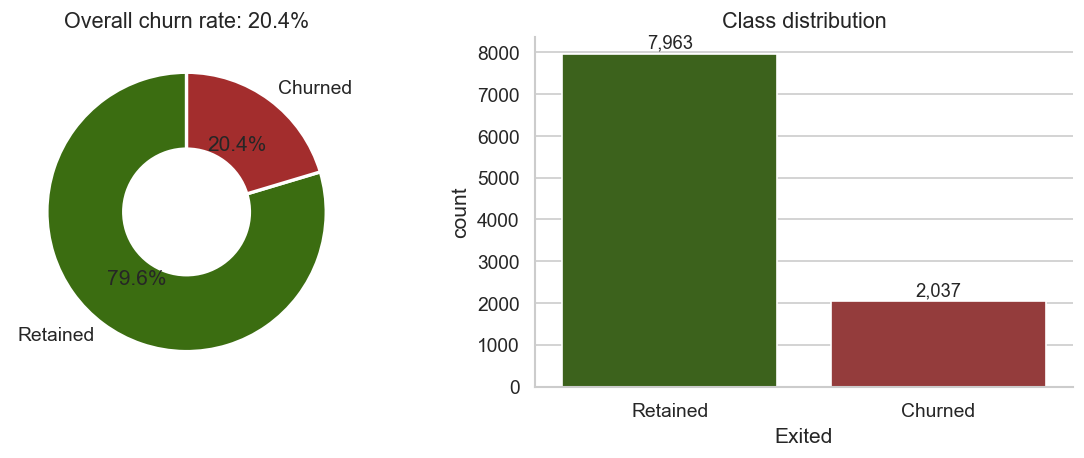

In [7]:
churn_rate = df['Exited'].mean()
print(f'Overall churn rate: {churn_rate:.2%}')
print(f'Class ratio (retained:churned): {(1-churn_rate)/churn_rate:.1f}:1')

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Donut chart
counts = df['Exited'].value_counts()
axes[0].pie(
    counts, labels=['Retained', 'Churned'],
    colors=[PALETTE['retained'], PALETTE['churned']],
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title(f'Overall churn rate: {churn_rate:.1%}', fontsize=13)

# Count bar
sns.countplot(x='Exited', data=df, ax=axes[1],
              palette=[PALETTE['retained'], PALETTE['churned']])
axes[1].set_xticklabels(['Retained', 'Churned'])
axes[1].set_title('Class distribution', fontsize=13)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height()):,}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 50),
                     ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

### 2. Churn by categorical variables

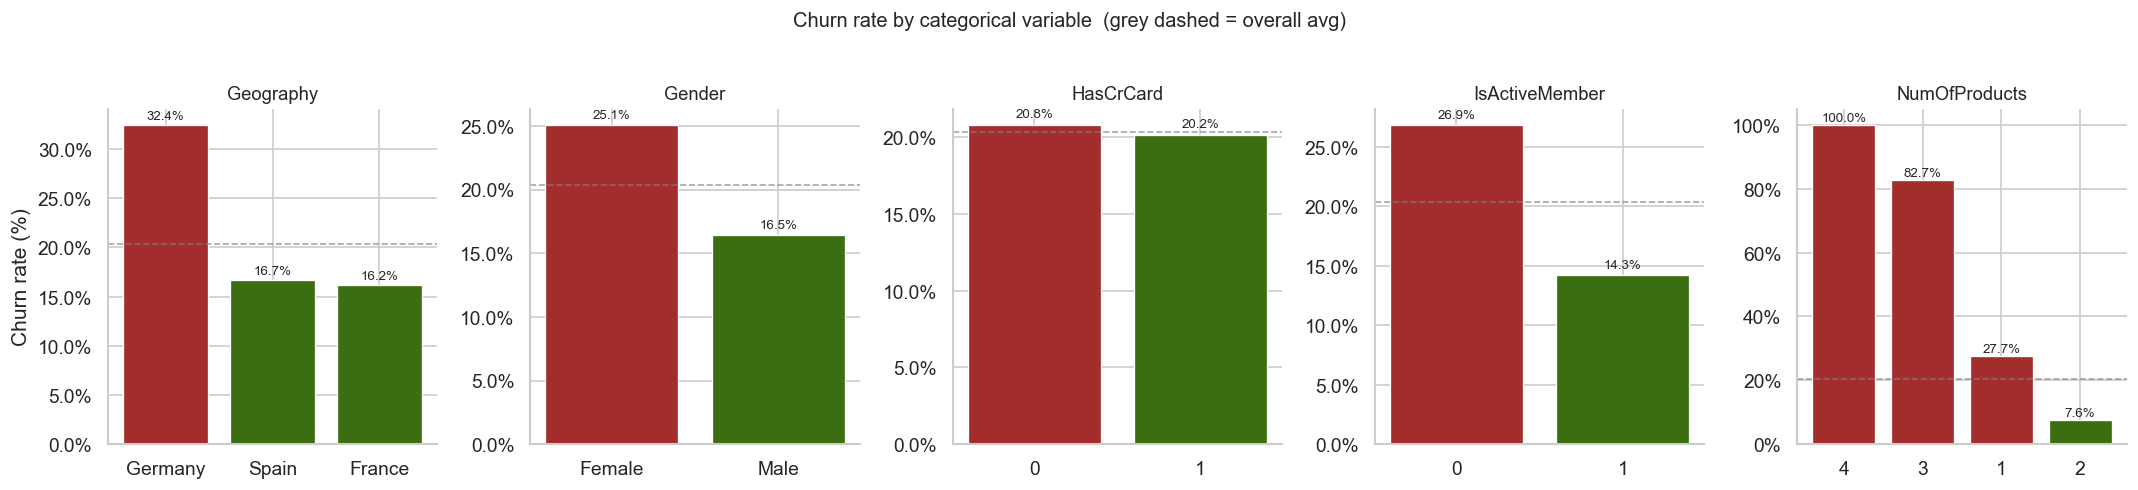

In [8]:
cat_vars = ['Geography', 'Gender', 'HasCrCard', 'IsActiveMember', 'NumOfProducts']
fig, axes = plt.subplots(1, len(cat_vars), figsize=(18, 4))

for ax, col in zip(axes, cat_vars):
    churn_by = (
        df.groupby(col)['Exited'].mean()
        .mul(100).reset_index().sort_values('Exited', ascending=False)
    )
    bars = ax.bar(
        churn_by[col].astype(str), churn_by['Exited'],
        color=[PALETTE['churned'] if v > churn_rate*100 else PALETTE['retained']
               for v in churn_by['Exited']],
        edgecolor='white', linewidth=0.8
    )
    ax.axhline(churn_rate*100, color='grey', lw=1, linestyle='--', alpha=0.7)
    ax.set_title(col, fontsize=11)
    if ax == axes[0]: ax.set_ylabel('Churn rate (%)')
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=8)

plt.suptitle('Churn rate by categorical variable  (grey dashed = overall avg)', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

### 3. Numeric feature distributions - churned vs retained

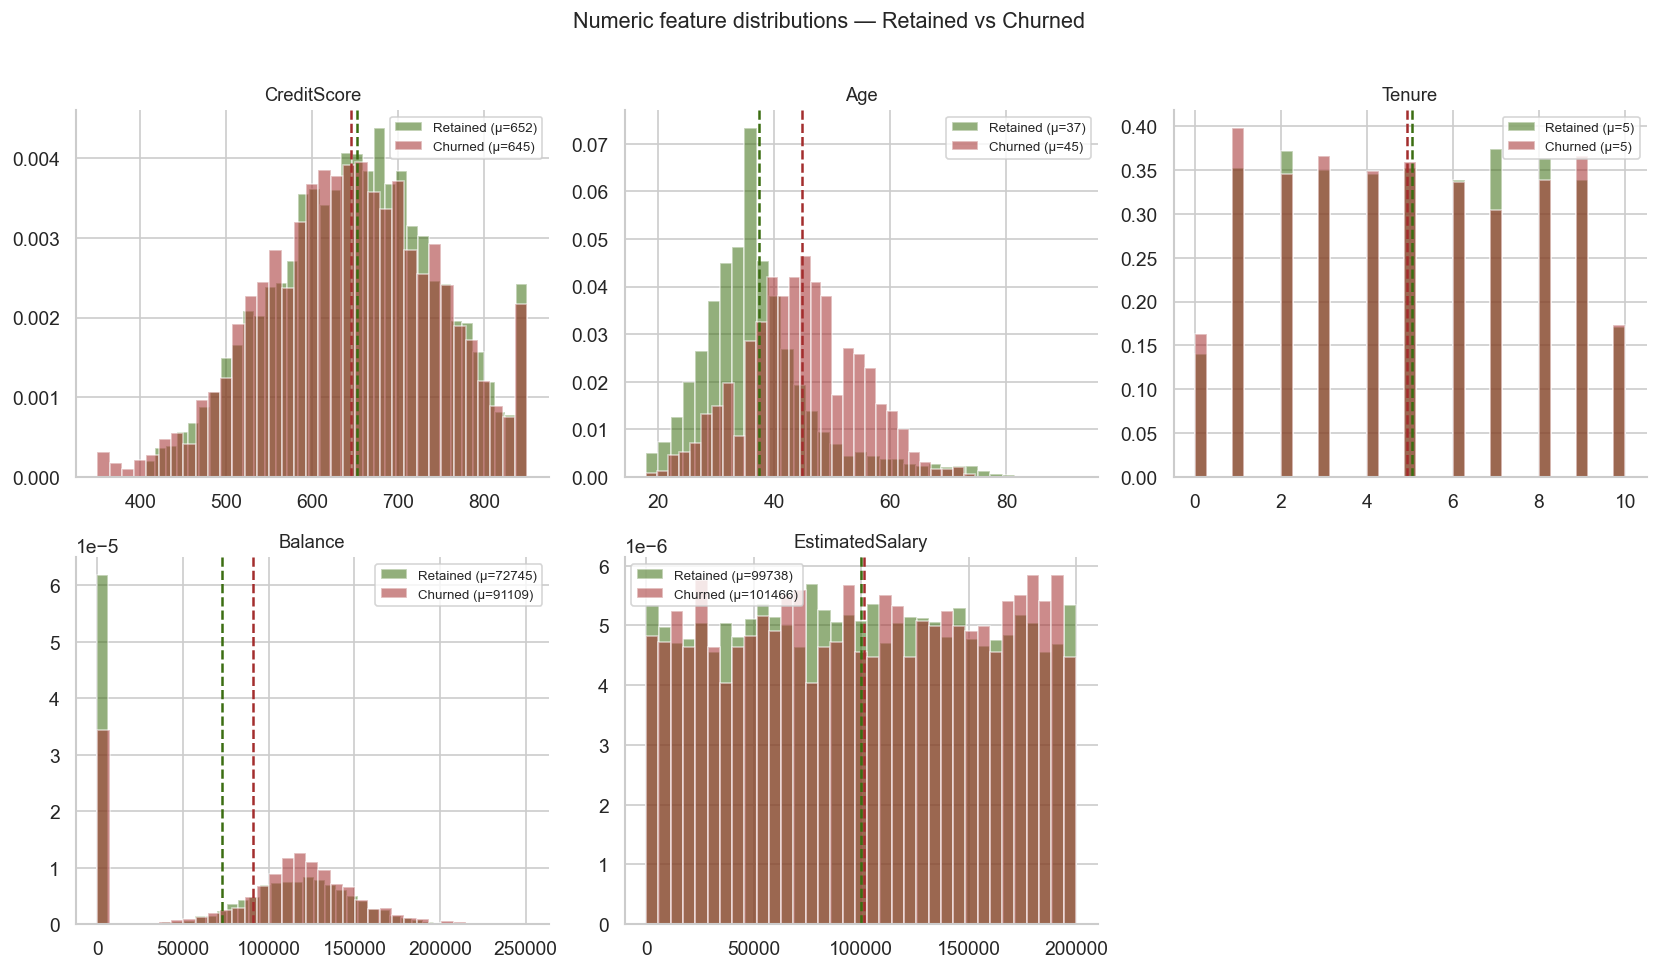

In [9]:
num_vars = ['CreditScore', 'Age', 'Tenure', 'Balance', 'EstimatedSalary']
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for ax, col in zip(axes, num_vars):
    for exited, label, color in [
        (0, 'Retained', PALETTE['retained']),
        (1, 'Churned',  PALETTE['churned']),
    ]:
        subset = df.loc[df['Exited'] == exited, col]
        ax.hist(subset, bins=35, alpha=0.55, color=color,
                label=f'{label} (μ={subset.mean():.0f})', density=True, edgecolor='white')
        ax.axvline(subset.mean(), color=color, lw=1.5, linestyle='--')
    ax.set_title(col, fontsize=11)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Numeric feature distributions — Retained vs Churned', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

### 4. Age band churn analysis

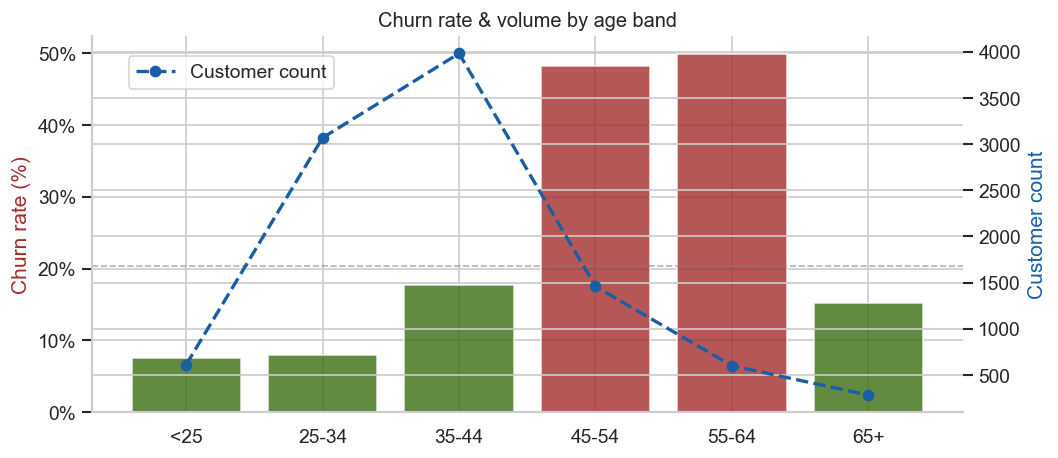

In [10]:
age_bins   = [0, 25, 34, 44, 54, 64, 100]
age_labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']
df['Age_Band'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=True)

age_churn = (
    df.groupby('Age_Band', observed=True)['Exited']
    .agg(['mean','count']).reset_index()
    .rename(columns={'mean':'churn_rate','count':'n'})
)

fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()

bars = ax1.bar(
    age_churn['Age_Band'].astype(str), age_churn['churn_rate']*100,
    color=[PALETTE['churned'] if r > churn_rate else PALETTE['retained']
           for r in age_churn['churn_rate']],
    alpha=0.8, edgecolor='white'
)
ax2.plot(age_churn['Age_Band'].astype(str), age_churn['n'],
         'o--', color=PALETTE['blue'], lw=2, ms=6, label='Customer count')

ax1.set_ylabel('Churn rate (%)', color=PALETTE['churned'])
ax2.set_ylabel('Customer count', color=PALETTE['blue'])
ax1.set_title('Churn rate & volume by age band', fontsize=12)
ax1.axhline(churn_rate*100, color='grey', lw=1, linestyle='--', alpha=0.6)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
fig.legend(loc='upper left', bbox_to_anchor=(0.12, 0.88))
plt.tight_layout()
plt.show()

### 5. Balance × Age scatter - coloured by churn status

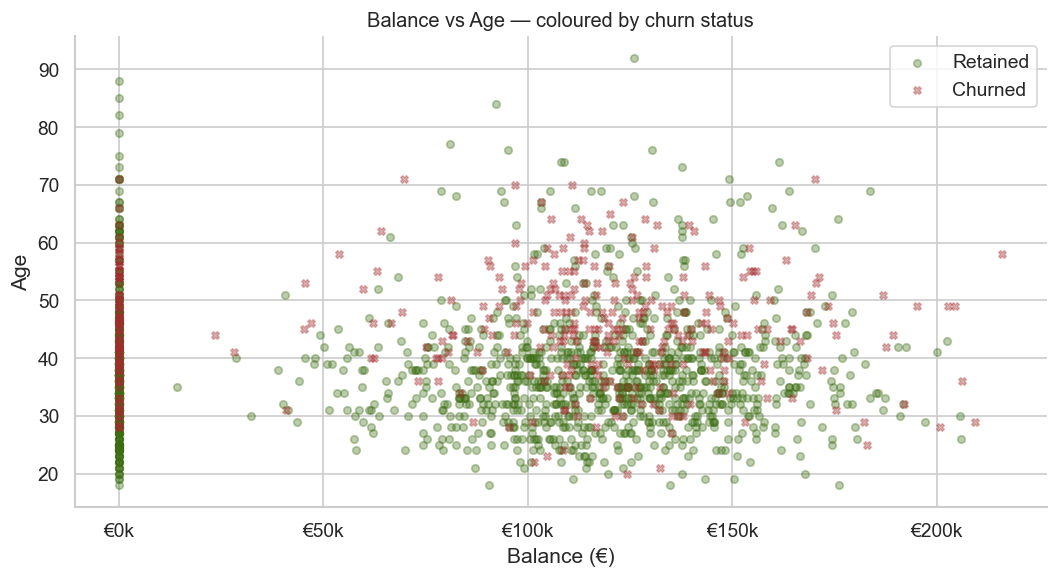

In [11]:
sample = df.sample(2000, random_state=42)
fig, ax = plt.subplots(figsize=(9, 5))
for exited, label, color, marker in [
    (0, 'Retained', PALETTE['retained'], 'o'),
    (1, 'Churned',  PALETTE['churned'],  'X'),
]:
    s = sample[sample['Exited'] == exited]
    ax.scatter(s['Balance'], s['Age'], alpha=0.35, s=20,
               color=color, label=label, marker=marker)
ax.set_xlabel('Balance (€)')
ax.set_ylabel('Age')
ax.set_title('Balance vs Age — coloured by churn status', fontsize=12)
ax.legend()
ax.xaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'€{x/1000:.0f}k'))
plt.tight_layout()
plt.show()

### 6. Products held × Churn - the non-linear relationship

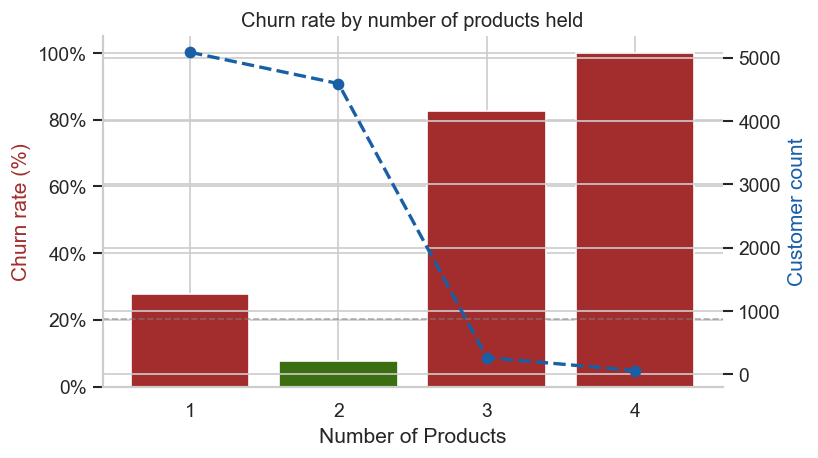

In [12]:
prod_churn = (
    df.groupby('NumOfProducts')['Exited']
    .agg(['mean','count']).reset_index()
    .rename(columns={'mean':'churn_rate','count':'n'})
)

fig, ax1 = plt.subplots(figsize=(7, 4))
ax2 = ax1.twinx()

bars = ax1.bar(
    prod_churn['NumOfProducts'].astype(str), prod_churn['churn_rate']*100,
    color=[PALETTE['churned'] if r > churn_rate else PALETTE['retained']
           for r in prod_churn['churn_rate']],
    edgecolor='white'
)
ax2.plot(prod_churn['NumOfProducts'].astype(str), prod_churn['n'],
         'o--', color=PALETTE['blue'], lw=2, ms=6, label='Customer count')

ax1.set_xlabel('Number of Products')
ax1.set_ylabel('Churn rate (%)', color=PALETTE['churned'])
ax2.set_ylabel('Customer count', color=PALETTE['blue'])
ax1.set_title('Churn rate by number of products held', fontsize=12)
ax1.axhline(churn_rate*100, color='grey', lw=1, linestyle='--', alpha=0.6)
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout()
plt.show()

⚠️ **Non-linear warning:** Customers with 1 product churn at ~27%, 2 products drops to ~7%, but customers with 3-4 products churn at 80-100%. This U-shape means `NumOfProducts` cannot be used as a simple linear feature. Perhaps tree-based models will pick this up.

### 7. Geography × Gender churn heatmap

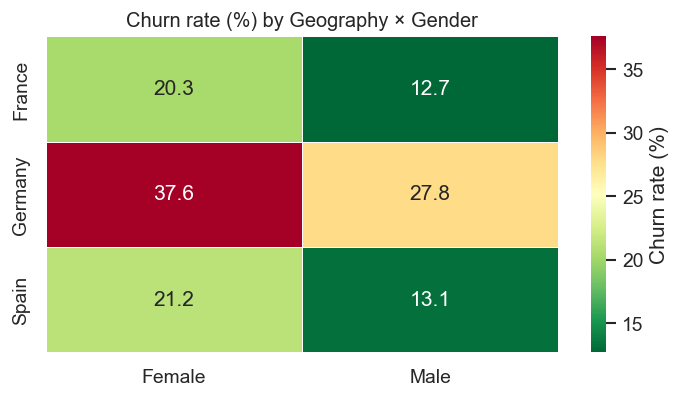

In [13]:
heat = (
    df.groupby(['Geography','Gender'])['Exited']
    .mean().mul(100).round(1)
    .unstack('Gender')
)

fig, ax = plt.subplots(figsize=(6, 3.5))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn rate (%)'})
ax.set_title('Churn rate (%) by Geography × Gender', fontsize=12)
ax.set_xlabel('')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## Correlation with Target

In [14]:
corr_matrix = df.corr(numeric_only=True)
churn_corr  = corr_matrix['Exited'].sort_values(ascending=False)
print(churn_corr)

Exited             1.000000
Age                0.285323
Balance            0.118533
EstimatedSalary    0.012097
HasCrCard         -0.007138
Tenure            -0.014001
CreditScore       -0.027094
NumOfProducts     -0.047820
IsActiveMember    -0.156128
Name: Exited, dtype: float64


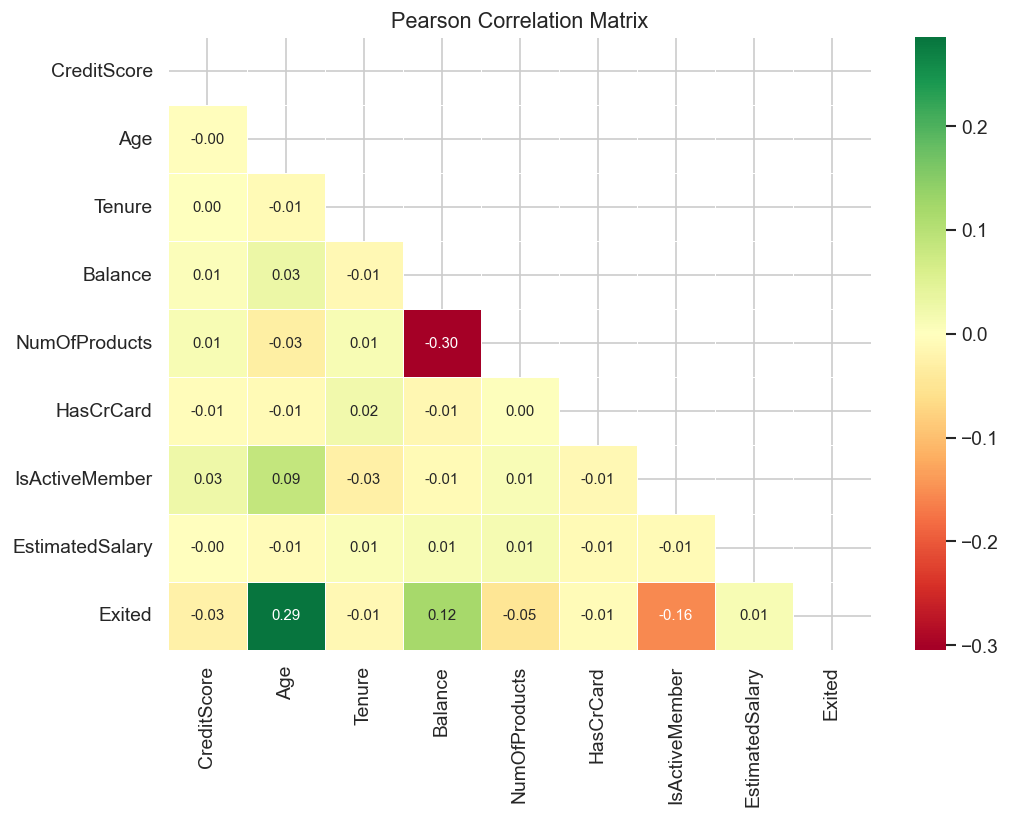

In [15]:
# Full correlation heatmap
fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 9})
ax.set_title('Pearson Correlation Matrix', fontsize=13)
plt.tight_layout()
plt.show()

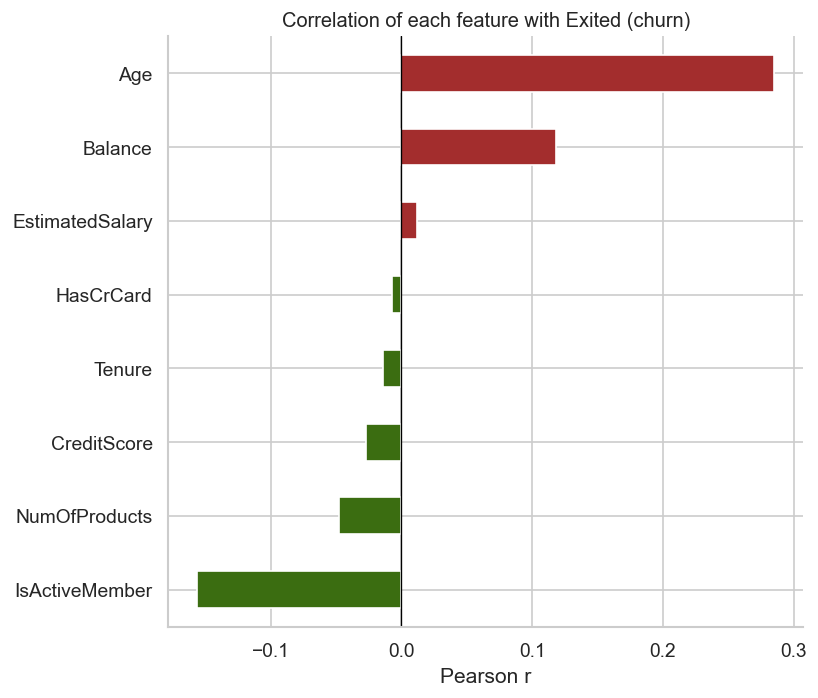

In [16]:
# Correlation with Exited only - sorted bar chart
corr_with_target = corr_matrix['Exited'].drop('Exited').sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
colors = [PALETTE['churned'] if v > 0 else PALETTE['retained'] for v in corr_with_target]
corr_with_target.plot(kind='barh', ax=ax, color=colors, edgecolor='white')
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlation of each feature with Exited (churn)', fontsize=12)
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

**Key correlations with churn (`Exited`):**

Positive (higher value → more likely to churn):
- `Age` (+0.29) → Older customers are significantly more likely to churn.
- `Balance` (+0.12) → Higher balance customers are slightly more likely to churn. The zero-balance segment is a special case.

Negative (higher value → less likely to churn):
- `IsActiveMember` (−0.16) → Active members have lower chance to churn compared to inactive ones.
- `NumOfProducts` (−0.05) → Though the correlation score is insignificant, it was observed that having 2 products is protective, but 3+ reverses this with a significant increase in churn rate. 

Weak / Noise:
- `CreditScore`, `Tenure`, `HasCrCard`, `EstimatedSalary` → Very weak individual correlations. May still add value in ensemble models through interaction with other features.

## RFM Engineering

Given no transaction recorded, in order to turn the problem into an RFM business case, I determined each factor (Recency, Frequency, Monetary) by combining the effects of variables that I assumed they shared some similarities. The table below demonstrates how R,F,M variables are formed:

| Dimension | Proxy | Rationale |
|---|---|---|
| **Recency** | `IsActiveMember` + `Tenure / 10` | Active + long-tenured = most recently engaged |
| **Frequency** | `NumOfProducts` | More products = more frequent touchpoints |
| **Monetary** | `Balance × 0.70 + EstimatedSalary × 0.30` | Combined asset value signal |

In [17]:
# # Step 1: Raw RFM proxies
# df['R_raw'] = (df['IsActiveMember'].astype(float) + df['Tenure'].astype(float) / 10).round(4)
# df['F_raw'] = df['NumOfProducts'].astype(float)
# df['M_raw'] = (df['Balance'] * 0.70 + df['EstimatedSalary'] * 0.30).round(2) 

# # Step 2: Quintile scores (1=lowest, 5=highest)
# # for dim, col in [('R','R_raw'), ('F','F_raw'), ('M','M_raw')]:
# #     # df[f'{dim}_score'] = (
# #     #     pd.qcut(df[col].rank(method='first'), q=5, labels=False, duplicates='drop') + 1 # +1 to convert 0-4 to 1-5
# #     # ).astype(int).clip(1, 5) 
# # Step 2: Stable SQL-like NTILE scoring


# # Step 3: Composite score (3–15) and cell string
# df['RFM_Score'] = df['R_score'] + df['F_score'] + df['M_score']
# df['RFM_Cell']  = df['R_score'].astype(str) + '-' + df['F_score'].astype(str) + '-' + df['M_score'].astype(str)

# # Step 4: Segment labels
# def rfm_segment(score):
#     if score >= 13: return 'Champion'
#     if score >= 10: return 'Loyal Customer'
#     if score >= 7:  return 'Potential Loyalist'
#     if score >= 4:  return 'At Risk'
#     return 'Lost / Hibernating'

# df['RFM_Segment'] = df['RFM_Score'].apply(rfm_segment)
# priority_map = {'Champion': 5, 'Loyal Customer': 4, 'Potential Loyalist': 3, 'At Risk': 2, 'Lost / Hibernating': 1}
# df['Retention_Priority'] = df['RFM_Segment'].map(priority_map)

# print('RFM columns added:')
# rfm_cols = ['R_raw','F_raw','M_raw','R_score','F_score','M_score','RFM_Score','RFM_Cell','RFM_Segment','Retention_Priority']
# print(rfm_cols)
# df[rfm_cols + ['Exited']].head(10)

### RFM Segment analysis

In [18]:
# seg_order  = ['Champion','Loyal Customer','Potential Loyalist','At Risk','Lost / Hibernating']
# seg_colors = ['#3B6D11','#639922','#EF9F27','#D85A30','#A32D2D']

# seg_summary = (
# df.groupby('RFM_Segment')
#     .agg(
#         count         = ('Exited', 'count'),
#         churn_rate    = ('Exited', 'mean'),
#         avg_rfm_score = ('RFM_Score', 'mean'),
#         avg_balance   = ('Balance', 'mean'),
#         avg_credit    = ('CreditScore', 'mean'),
#         avg_age       = ('Age', 'mean'),
#         avg_products  = ('NumOfProducts', 'mean'),
#         active_pct    = ('IsActiveMember', 'mean'),
#     )
#     .assign(
#         churn_rate = lambda d: d['churn_rate'].mul(100).round(1),
#         active_pct = lambda d: d['active_pct'].mul(100).round(1),
#         avg_balance= lambda d: d['avg_balance'].round(0),
#     )
#     .reindex(seg_order)
# )

# seg_summary.style.background_gradient(subset='churn_rate', cmap='RdYlGn_r')

In [19]:
# # Segment size and churn rate side-by-side
# fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# counts = df['RFM_Segment'].value_counts().reindex(seg_order)
# axes[0].barh(counts.index[::-1], counts.values[::-1], color=seg_colors[::-1], edgecolor='white')
# axes[0].set_xlabel('Number of customers')
# axes[0].set_title('Segment size', fontsize=12)
# for i, v in enumerate(counts.values[::-1]):
#     axes[0].text(v + 30, i, f'{v:,}', va='center', fontsize=9)

# churn_seg = seg_summary['churn_rate'].reindex(seg_order)
# axes[1].barh(seg_order[::-1], churn_seg.values[::-1], color=seg_colors[::-1], edgecolor='white')
# axes[1].set_xlabel('Churn rate (%)')
# axes[1].set_title('Churn rate per segment', fontsize=12)
# axes[1].axvline(churn_rate*100, color='grey', lw=1.2, linestyle='--')
# for i, v in enumerate(churn_seg.values[::-1]):
#     axes[1].text(v + 0.3, i, f'{v:.1f}%', va='center', fontsize=9)

# plt.suptitle('RFM Segment Overview', fontsize=13, y=1.01)
# plt.tight_layout()
# plt.show()

In [20]:
# # Geography × Segment churn heatmap
# heat_seg = (
#     df.groupby(['RFM_Segment','Geography'])['Exited']
#     .mean().mul(100).round(1)
#     .unstack('Geography')
#     .reindex(seg_order)
# )

# fig, ax = plt.subplots(figsize=(7, 4))
# sns.heatmap(heat_seg, annot=True, fmt='.1f', cmap='RdYlGn_r',
#             linewidths=0.5, ax=ax, cbar_kws={'label': 'Churn rate (%)'})
# ax.set_title('Churn rate (%) — RFM Segment × Geography', fontsize=12)
# ax.set_xlabel('')
# ax.set_ylabel('')
# plt.tight_layout()
# plt.show()

In [21]:
# # RFM Score distribution by churn status
# fig, ax = plt.subplots(figsize=(10, 4))
# for exited, label, color in [(0,'Retained',PALETTE['retained']),(1,'Churned',PALETTE['churned'])]:
#     subset = df[df['Exited']==exited]['RFM_Score']
#     ax.hist(subset, bins=range(3,17), alpha=0.6, color=color,
#             label=f'{label} (μ={subset.mean():.1f})', edgecolor='white', density=True)
#     ax.axvline(subset.mean(), color=color, lw=2, linestyle='--')
# ax.set_xlabel('Composite RFM Score (3–15)')
# ax.set_ylabel('Density')
# ax.set_title('RFM Score distribution — Retained vs Churned', fontsize=12)
# ax.legend()
# plt.tight_layout()
# plt.show()

## Feature Engineering for ML

In [22]:
# Interaction features
df['Balance_Salary_Ratio']  = (df['Balance'] / df['EstimatedSalary'].replace(0, np.nan)).fillna(0)
df['Products_per_Tenure']   = (df['NumOfProducts'] / df['Tenure'].replace(0, np.nan)).fillna(0)
df['Balance_per_Product']   = (df['Balance'] / df['NumOfProducts']).fillna(0)
df['CreditScore_Age_Ratio'] = (df['CreditScore'] / df['Age']).fillna(0)

# Balance band
balance_bins   = [-1, 0, 25_000, 50_000, 100_000, 150_000, 1e9]
balance_labels = ['Zero','1-25k','25-50k','50-100k','100-150k','150k+']
df['Balance_Band'] = pd.cut(df['Balance'], bins=balance_bins, labels=balance_labels, right=True).astype(str)

print('New feature columns:', ['Balance_Salary_Ratio','Products_per_Tenure','Balance_per_Product',
                                'CreditScore_Age_Ratio','Balance_Band'])
df[['Balance_Salary_Ratio','Products_per_Tenure','Balance_per_Product','CreditScore_Age_Ratio','Balance_Band']].head(5)

New feature columns: ['Balance_Salary_Ratio', 'Products_per_Tenure', 'Balance_per_Product', 'CreditScore_Age_Ratio', 'Balance_Band']


,Balance_Salary_Ratio,Products_per_Tenure,Balance_per_Product,CreditScore_Age_Ratio,Balance_Band
0,0.000000,0.500,0.000000,14.738095,Zero
1,0.744677,1.000,83807.860000,14.829268,50-100k
2,1.401375,0.375,53220.266667,11.952381,150k+
3,0.000000,2.000,0.000000,17.923077,Zero
4,1.587055,0.500,125510.820000,19.767442,100-150k


In [23]:
# One-hot encode categorical columns
ohe_cols = ['Geography', 'Gender', 'Age_Band', 'Balance_Band']
df_enc   = pd.get_dummies(df, columns=ohe_cols, drop_first=False, dtype=int)

# Drop raw RFM intermediates and identifier-like columns
drop_cols = ['R_raw','F_raw','M_raw','RFM_Cell','Age_Band']
df_enc    = df_enc.drop(columns=[c for c in drop_cols if c in df_enc.columns], errors='ignore')

print(f'Feature matrix after encoding: {df_enc.shape}')
df_enc.head(3)

Feature matrix after encoding: (10000, 30)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Balance_Salary_Ratio,Products_per_Tenure,Balance_per_Product,CreditScore_Age_Ratio,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male,Age_Band_<25,Age_Band_25-34,Age_Band_35-44,Age_Band_45-54,Age_Band_55-64,Age_Band_65+,Balance_Band_1-25k,Balance_Band_100-150k,Balance_Band_150k+,Balance_Band_25-50k,Balance_Band_50-100k,Balance_Band_Zero
0,619,42,2,0.00,1,1,1,101348.88,1,0.000000,0.500,0.000000,14.738095,1,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1
1,608,41,1,83807.86,1,0,1,112542.58,0,0.744677,1.000,83807.860000,14.829268,0,0,1,1,0,0,0,1,0,0,0,0,0,0,0,1,0
2,502,42,8,159660.80,3,1,0,113931.57,1,1.401375,0.375,53220.266667,11.952381,1,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0


## Multicollinearity (VIF)

In [24]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Select ONLY numeric columns
X_vif = df_enc.drop(columns=['Exited']).select_dtypes(include=[np.number])

# Remove any rows with NaN or infinite values
X_vif = X_vif.replace([np.inf, -np.inf], np.nan).dropna()

vif_data = pd.DataFrame({
    'feature': X_vif.columns,
    'VIF'    : [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False)

print(vif_data.to_string(index=False))

              feature       VIF
     Geography_France       inf
Balance_Band_100-150k       inf
   Balance_Band_1-25k       inf
         Age_Band_65+       inf
       Age_Band_55-64       inf
       Age_Band_45-54       inf
       Age_Band_35-44       inf
       Age_Band_25-34       inf
         Age_Band_<25       inf
          Gender_Male       inf
        Gender_Female       inf
      Geography_Spain       inf
    Geography_Germany       inf
   Balance_Band_150k+       inf
  Balance_Band_25-50k       inf
 Balance_Band_50-100k       inf
    Balance_Band_Zero       inf
              Balance 45.431002
                  Age 39.806467
CreditScore_Age_Ratio 29.974672
  Balance_per_Product 14.164735
          CreditScore  8.289668
        NumOfProducts  3.215855
  Products_per_Tenure  1.901170
               Tenure  1.647994
       IsActiveMember  1.024989
      EstimatedSalary  1.005359
 Balance_Salary_Ratio  1.005012
            HasCrCard  1.003592


- Multicollinearity is present among OHE dummies (expected - e.g. Geography dummies sum to 1).
- For tree-based models (XGBoost, Random Forest) this is acceptable: split selection is based on impurity reduction, not linear coefficients — redundant features simply compete but do not cause unstable predictions.
- If deploying a logistic regression, drop one dummy per group and apply L2 regularisation.

## Machine Learning

In [25]:
# Class balance check
print('Class balance:')
print(df_enc['Exited'].value_counts())
print(f'\nChurn rate: {df_enc["Exited"].mean():.2%}')

Class balance:
Exited
0    7963
1    2037
Name: count, dtype: int64

Churn rate: 20.37%


            **Class imbalance (~20% churners):**
Given this moderate imbalance, `class_weight='balanced'` / `scale_pos_weight` plus threshold tuning is sufficient. No aggressive oversampling required upfront.

**Metric priority for churn prediction:**
- **Recall** is usually most important — missing a churner (False Negative) costs more than contacting a loyal customer (False Positive).
- If retention campaigns are expensive → balance precision and recall using **F1 score**.
- For ranking churn risk → use **ROC-AUC** or **PR-AUC**.

In [26]:
from sklearn.model_selection import train_test_split
# Clean column names - XGBoost doesn't allow special characters like <, >, [, ], or spaces
df_enc.columns = df_enc.columns.str.replace(r'[<>\[\]]', '', regex=True).str.replace(r'[\s\-]', '_', regex=True)

print("Cleaned column names (first 15):")
print(df_enc.columns.tolist()[:15])
X = df_enc.drop(columns=['Exited'])
y = df_enc['Exited']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape} | positive rate: {y_train.mean():.2%}')
print(f'Test:  {X_test.shape}  | positive rate: {y_test.mean():.2%}')

THRESHOLD = 0.40   # slightly below 0.5 to boost recall; tune per business needs

Cleaned column names (first 15):
['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Balance_Salary_Ratio', 'Products_per_Tenure', 'Balance_per_Product', 'CreditScore_Age_Ratio', 'Geography_France', 'Geography_Germany']
Train: (8000, 29) | positive rate: 20.38%
Test:  (2000, 29)  | positive rate: 20.35%


### Random Forest Classifier

In [27]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

proba  = rf.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)

print(classification_report(y_test, y_pred, digits=3))

              precision    recall  f1-score   support

           0      0.887     0.932     0.909      1593
           1      0.668     0.533     0.593       407

    accuracy                          0.851      2000
   macro avg      0.777     0.733     0.751      2000
weighted avg      0.842     0.851     0.845      2000



In [28]:
from sklearn.metrics import precision_score, recall_score, f1_score

proba = rf.predict_proba(X_test)[:, 1]
print('Threshold tuning for RandomForest')
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    print(f"{thresh:<8}{precision_score(y_test, preds):<8.3f}"
          f"{recall_score(y_test, preds):<8.3f}{f1_score(y_test, preds):<8.3f}")

Threshold tuning for RandomForest
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.530   0.705   0.605   
0.3     0.585   0.644   0.613   
0.35    0.630   0.585   0.606   
0.4     0.668   0.533   0.593   
0.45    0.721   0.477   0.574   
0.5     0.793   0.432   0.560   


### XGBoost Classifier

In [29]:
from xgboost import XGBClassifier
import time

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=500, learning_rate=0.05, max_depth=6,
    subsample=0.8, colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss', random_state=42, n_jobs=-1
)

start_train = time.time()
xgb.fit(X_train, y_train)
print(f'⏱ Training: {time.time()-start_train:.2f}s')

start_pred = time.time()
proba  = xgb.predict_proba(X_test)[:, 1]
y_pred = (proba >= THRESHOLD).astype(int)
print(f'⏱ Prediction: {time.time()-start_pred:.4f}s')

print(classification_report(y_test, y_pred, digits=3))

⏱ Training: 0.67s
⏱ Prediction: 0.0060s
              precision    recall  f1-score   support

           0      0.915     0.839     0.875      1593
           1      0.524     0.693     0.597       407

    accuracy                          0.809      2000
   macro avg      0.719     0.766     0.736      2000
weighted avg      0.835     0.809     0.819      2000



In [30]:
proba = xgb.predict_proba(X_test)[:, 1]
print('Threshold tuning for XGBoost')
print(f"{'Thresh':<8}{'Prec_1':<8}{'Rec_1':<8}{'F1_1':<8}")
for thresh in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    preds = (proba >= thresh).astype(int)
    print(f"{thresh:<8}{precision_score(y_test, preds):<8.3f}"
          f"{recall_score(y_test, preds):<8.3f}{f1_score(y_test, preds):<8.3f}")

Threshold tuning for XGBoost
Thresh  Prec_1  Rec_1   F1_1    
0.25    0.443   0.794   0.569   
0.3     0.467   0.759   0.578   
0.35    0.497   0.730   0.591   
0.4     0.524   0.693   0.597   
0.45    0.564   0.668   0.612   
0.5     0.591   0.639   0.614   


## Hyperparameter Tuning (Optuna) & Experiment Tracking (MLflow)

In [31]:
import optuna
from sklearn.metrics import recall_score

def objective(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 300, 800),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.2),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight' : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 5),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 5),
        'random_state'     : 42,
        'n_jobs'           : -1,
        'scale_pos_weight' : scale_pos_weight,
        'eval_metric'      : 'logloss',
    }
    model  = XGBClassifier(**params)
    model.fit(X_train, y_train)
    proba  = model.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    return recall_score(y_test, y_pred, pos_label=1)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print('Best Params:', study.best_params)
print('Best Recall:', study.best_value)

[I 2026-04-25 12:44:43,139] A new study created in memory with name: no-name-ce351987-9274-4190-9cdc-25d0b61b2e3c
[I 2026-04-25 12:44:43,326] Trial 0 finished with value: 0.8230958230958231 and parameters: {'n_estimators': 448, 'learning_rate': 0.08486699044722425, 'max_depth': 4, 'subsample': 0.8449147070451801, 'colsample_bytree': 0.6038028864886941, 'min_child_weight': 9, 'gamma': 4.529385554127632, 'reg_alpha': 1.5353943582002338, 'reg_lambda': 3.193084817719477}. Best is trial 0 with value: 0.8230958230958231.
[I 2026-04-25 12:44:43,819] Trial 1 finished with value: 0.800982800982801 and parameters: {'n_estimators': 467, 'learning_rate': 0.015314328391613403, 'max_depth': 6, 'subsample': 0.5864922753418957, 'colsample_bytree': 0.8157636265377122, 'min_child_weight': 7, 'gamma': 3.386621429885148, 'reg_alpha': 1.768405715479462, 'reg_lambda': 1.6663253176689956}. Best is trial 0 with value: 0.8230958230958231.
[I 2026-04-25 12:44:44,042] Trial 2 finished with value: 0.7714987714987

Best Params: {'n_estimators': 647, 'learning_rate': 0.030444991938011427, 'max_depth': 3, 'subsample': 0.9959669831302239, 'colsample_bytree': 0.9030731768283279, 'min_child_weight': 2, 'gamma': 1.942686449916779, 'reg_alpha': 4.338472125479487, 'reg_lambda': 3.445668957138454}
Best Recall: 0.8427518427518428


In [32]:
import mlflow
import mlflow.xgboost
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import os

# Force MLflow to use the project root's mlruns folder with proper file:// URI scheme
mlruns_path = os.path.abspath("./mlruns")
print(mlruns_path)
mlflow.set_tracking_uri(f"file:///{mlruns_path.replace(chr(92), '/')}")
mlflow.set_experiment('Bank Churn - XGBoost')

with mlflow.start_run():
    best_params = study.best_params.copy()
    best_params.update({
        'random_state'     : 42,
        'n_jobs'           : -1,
        'scale_pos_weight' : scale_pos_weight,
        'eval_metric'      : 'logloss',
    })
    mlflow.log_params(best_params)

    start_train = time.time()
    xgb_best = XGBClassifier(**best_params)
    xgb_best.fit(X_train, y_train)
    mlflow.log_metric('train_time', time.time() - start_train)

    start_pred = time.time()
    proba  = xgb_best.predict_proba(X_test)[:, 1]
    y_pred = (proba >= THRESHOLD).astype(int)
    mlflow.log_metric('pred_time', time.time() - start_pred)

    mlflow.log_metric('precision', precision_score(y_test, y_pred))
    mlflow.log_metric('recall',    recall_score(y_test, y_pred))
    mlflow.log_metric('f1',        f1_score(y_test, y_pred))
    mlflow.log_metric('roc_auc',   roc_auc_score(y_test, proba))

    mlflow.xgboost.log_model(xgb_best, 'model')

    print(classification_report(y_test, y_pred, digits=3))

c:\Users\Loc-kun\Documents\GitHub\Loc-s-projects-\Bank_churn_analysis\mlruns


2026/04/25 12:44:53 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


              precision    recall  f1-score   support

           0      0.946     0.711     0.812      1593
           1      0.427     0.843     0.566       407

    accuracy                          0.738      2000
   macro avg      0.687     0.777     0.689      2000
weighted avg      0.841     0.738     0.762      2000



### Tuned XGBoost Confusion Matrix

This matrix shows how the tuned XGBoost model classifies retained versus churned customers on the test set at the selected decision threshold.


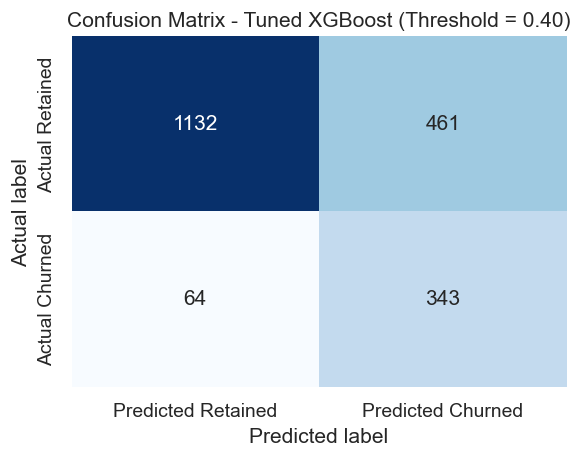

array([[1132,  461],
       [  64,  343]])

In [33]:
from sklearn.metrics import confusion_matrix

# Recompute the tuned-model predictions explicitly for the confusion matrix view
proba_test = xgb_best.predict_proba(X_test)[:, 1]
y_pred_test = (proba_test >= THRESHOLD).astype(int)
cm = confusion_matrix(y_test, y_pred_test)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Predicted Retained", "Predicted Churned"],
    yticklabels=["Actual Retained", "Actual Churned"],
    ax=ax,
)
ax.set_title(f"Confusion Matrix - Tuned XGBoost (Threshold = {THRESHOLD:.2f})")
ax.set_xlabel("Predicted label")
ax.set_ylabel("Actual label")
plt.tight_layout()
plt.show()

cm

## SHAP Explainability

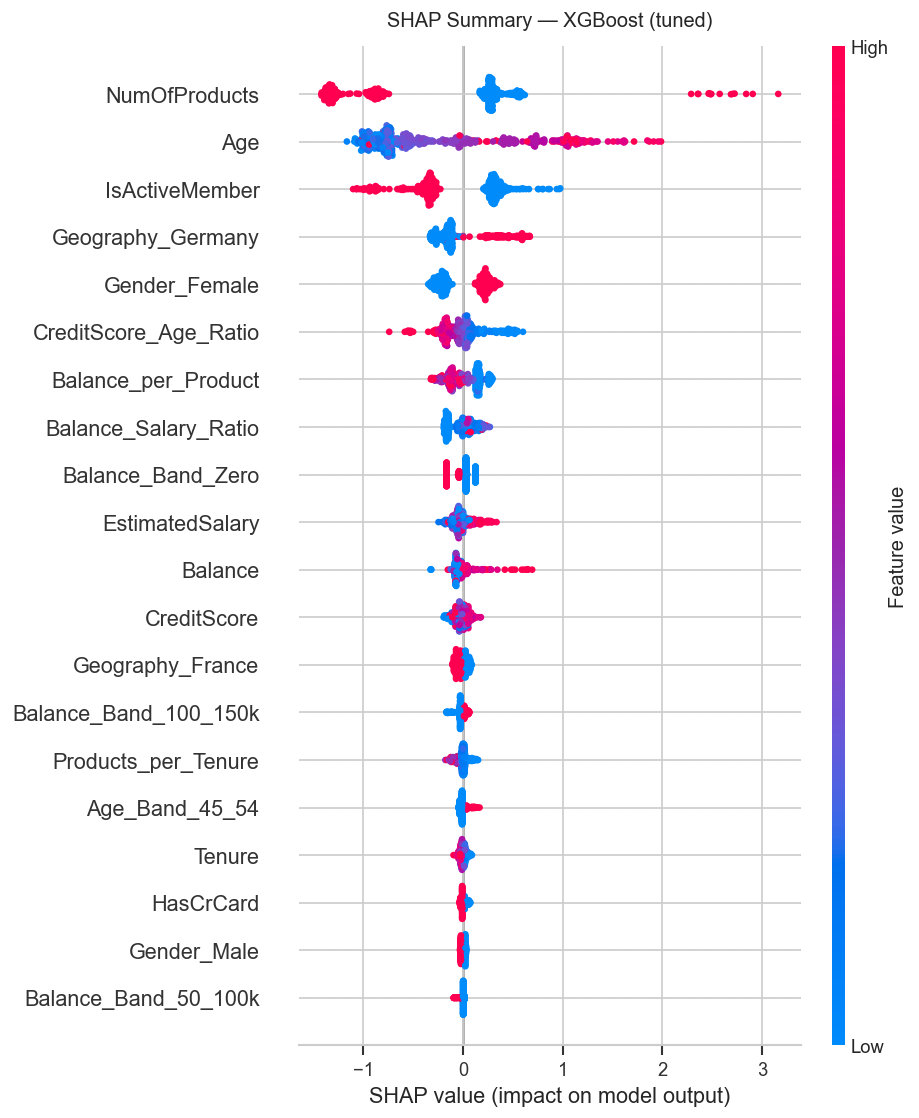

In [34]:
import shap

explainer   = shap.TreeExplainer(xgb_best)
shap_values = explainer.shap_values(X_test[:500])

# Summary (beeswarm)
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test[:500], feature_names=X_test.columns.tolist(), show=False)
plt.title('SHAP Summary — XGBoost (tuned)', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

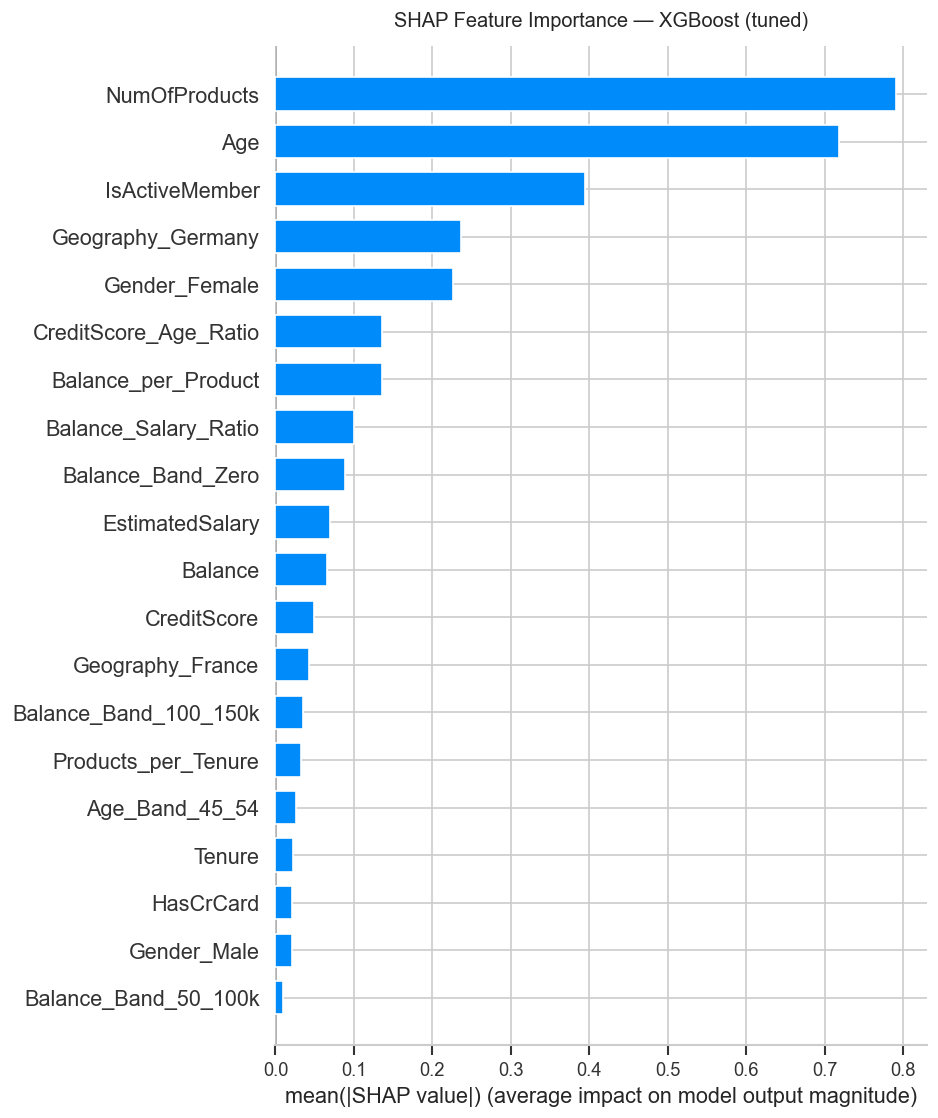

In [35]:
# SHAP bar — feature importance
plt.figure(figsize=(8, 6))
shap.summary_plot(shap_values, X_test[:500], feature_names=X_test.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance — XGBoost (tuned)', fontsize=12, pad=12)
plt.tight_layout()
plt.show()

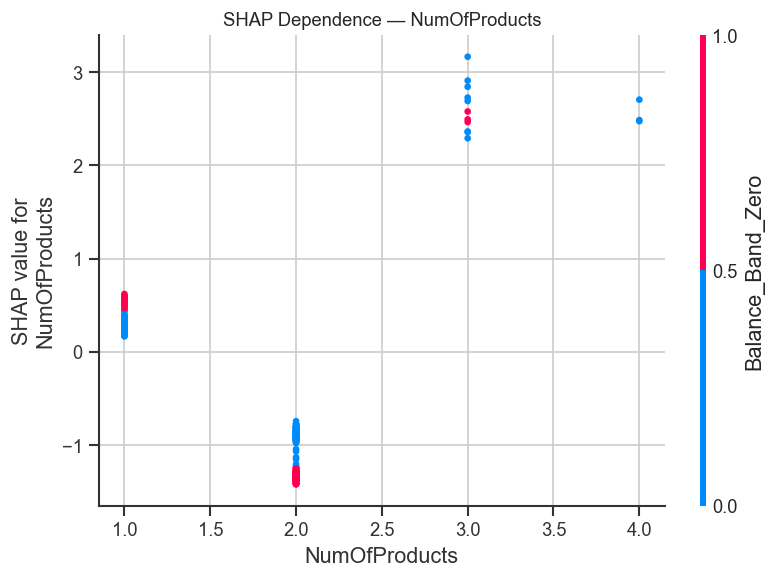

In [36]:
# Dependence plot for top feature (Age is typically highest)
mean_abs = np.abs(shap_values).mean(axis=0)
top_feat = X_test.columns[np.argmax(mean_abs)]

fig, ax = plt.subplots(figsize=(7, 5))
shap.dependence_plot(top_feat, shap_values, X_test[:500].values,
                     feature_names=X_test.columns.tolist(), show=False, ax=ax)
ax.set_title(f'SHAP Dependence — {top_feat}', fontsize=11)
plt.tight_layout()
plt.show()

In [37]:
import shap
import numpy as np

# Get SHAP explainer
explainer = shap.TreeExplainer(xgb_best)
shap_values_raw = explainer.shap_values(X_test[:500])

# Debug: Check the structure
print(f"Type of shap_values_raw: {type(shap_values_raw)}")
print(f"Shape: {np.array(shap_values_raw).shape if isinstance(shap_values_raw, list) else shap_values_raw.shape}")

# For binary classification, extract the positive class (churn = 1)
# If it's a list, take the second element; if it's 3D array, take [:, :, 1]
if isinstance(shap_values_raw, list):
    shap_values = np.array(shap_values_raw[1])  # Convert to array

print(f"SHAP values shape: {shap_values.shape}")

# Calculate mean absolute SHAP value per feature
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Create ranked dataframe
shap_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": mean_abs_shap
}).sort_values("Importance", ascending=False).reset_index(drop=True)

print(shap_df.head(10))

Type of shap_values_raw: <class 'numpy.ndarray'>
Shape: (500, 29)
SHAP values shape: (500, 29)
                 Feature  Importance
0          NumOfProducts    0.789982
1                    Age    0.718442
2         IsActiveMember    0.394358
3      Geography_Germany    0.236291
4          Gender_Female    0.226417
5  CreditScore_Age_Ratio    0.135876
6    Balance_per_Product    0.135749
7   Balance_Salary_Ratio    0.099924
8      Balance_Band_Zero    0.088526
9        EstimatedSalary    0.069818


## Churn Probability Score Distribution

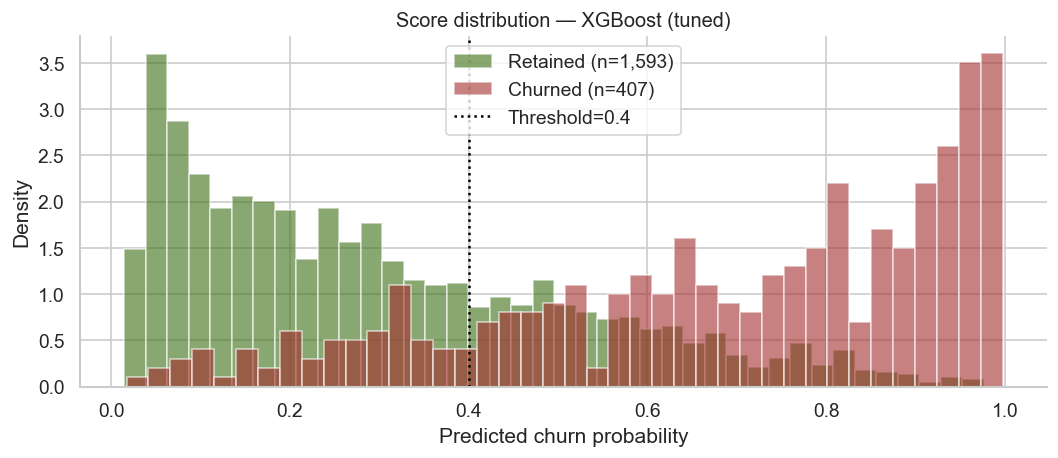

In [38]:
proba = xgb_best.predict_proba(X_test)[:, 1]

fig, ax = plt.subplots(figsize=(9, 4))
for exited, label, color in [(0,'Retained',PALETTE['retained']),(1,'Churned',PALETTE['churned'])]:
    ax.hist(proba[y_test==exited], bins=40, alpha=0.6, color=color,
            label=f'{label} (n={int((y_test==exited).sum()):,})',
            density=True, edgecolor='white')
ax.axvline(THRESHOLD, color='black', lw=1.5, linestyle=':', label=f'Threshold={THRESHOLD}')
ax.set_xlabel('Predicted churn probability')
ax.set_ylabel('Density')
ax.set_title('Score distribution — XGBoost (tuned)', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

## Export Churn Scores for Existing Non-Churned Customers

This section scores customers who have not yet churned (`Exited = 0`) using the tuned XGBoost model. The output can be used for retention prioritisation, CRM upload, or dashboard reporting.


In [39]:
# Score only customers who have not yet churned
SCORING_THRESHOLD = 0.50

# X contains the final model-ready feature matrix created above.
# y contains the original churn label, where 0 = retained / not yet churned.
not_churned_mask = y.eq(0)
X_scoring = X.loc[not_churned_mask].copy()
scoring_customer_ids = customer_ids.loc[X_scoring.index].reset_index(drop=True)

# Use the tuned XGBoost model trained in the MLflow section.
predicted_prob = xgb_best.predict_proba(X_scoring)[:, 1]
predicted_label = (predicted_prob >= SCORING_THRESHOLD).astype(int)

scoring_output = pd.DataFrame({
    "CustomerId": scoring_customer_ids,
    "Predicted_Churn_Probability": predicted_prob,
    "Predicted_Churn_Label": predicted_label,
})

scoring_output["Risk_Tier"] = pd.cut(
    scoring_output["Predicted_Churn_Probability"],
    bins=[0, 0.30, 0.60, 1.00],
    labels=["Low", "Medium", "High"],
    include_lowest=True,
)

# Sort highest-risk active customers first for retention action.
scoring_output = scoring_output.sort_values(
    "Predicted_Churn_Probability", ascending=False
).reset_index(drop=True)

output_path = "bank_churn_predictions.csv"
scoring_output.to_csv(output_path, index=False)

print(f"Scored {len(scoring_output):,} non-churned customers")
print(f"Saved prediction file to: {output_path}")
scoring_output.head(10)


Scored 7,963 non-churned customers
Saved prediction file to: bank_churn_predictions.csv


,CustomerId,Predicted_Churn_Probability,Predicted_Churn_Label,Risk_Tier
0,15797960,0.981981,1,High
1,15791321,0.977612,1,High
2,15789582,0.976576,1,High
3,15699523,0.966703,1,High
4,15691119,0.964900,1,High
5,15771728,0.961743,1,High
6,15579826,0.956510,1,High
7,15657468,0.956401,1,High
8,15769917,0.954559,1,High
9,15691504,0.954551,1,High


## Summary & Next Steps

### Key findings

1. **Age is the strongest churn driver** with the 51-60 cohort churns at >50%. Older customers disengage and need direct contact to be retained.
2. **Products held is non-linear** - 2 products is the sweet spot (churn ~7%); 3-4 products see extreme churn (80-100%), likely because those customers are being over-sold.
3. **Inactive members churn at ~2× the rate** of active members - re-activation is a high-ROI intervention.
4. **Germany drives disproportionate churn** across every RFM segment - a structural country-level issue requiring dedicated investigation.
5. **Female customers churn ~52% more** than male customers - gender-targeted retention messaging is warranted.
6. **Zero-balance customers** present a dual risk: no financial stake → no retention leverage.

### Model recommendation
- **XGBoost (tuned via Optuna)** is recommended as the production model - best balance of recall and training speed.
- Decision threshold should be set at **0.35-0.40** for aggressive retention campaigns; raise to **0.45-0.50** if campaign cost is high.

### Next steps
- Feed churn probability scores back into the Power BI dashboard as a customer-level column.
- Implement the full `src/` modular pipeline via `scripts/train_pipeline.py`.
- Deploy the FastAPI app (`make serve`) and integrate the `/predict` endpoint with the CRM system.